# Effects of Violations of Independence Assumption: Clustered Data

This notebook demonstrates how violations of the independence assumption affect statistical testing when data has a clustered structure. We'll compare:

1. **Independent data**: Observations with a true fixed effect plus independent noise
2. **Clustered data**: Same fixed effect plus cluster-level random intercepts plus the same noise

Both datasets receive the same true signal (on average) and the same observation-level noise. The only difference is that the clustered data has additional group-level variability in the effect size (random intercepts).

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import pandas as pd
import warnings
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.stats.sandwich_covariance import cov_cluster

from pathlib import Path

FIGURE_DIR = Path('../../book/book/images')

# Set random seed for reproducibility
np.random.seed(42)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

# Suppress convergence warnings from mixed effects models
# These occur when random effects variance is near zero (boundary condition)
warnings.filterwarnings('ignore', category=RuntimeWarning, module='statsmodels')
warnings.filterwarnings('ignore', message='.*convergence.*', category=UserWarning)

In [2]:
# Setup rpy2 for R integration (lmerTest)
# This notebook requires R with lme4 and lmerTest packages to compare
# Python and R mixed effects implementations

import rpy2.robjects as ro
from rpy2.robjects import pandas2ri, numpy2ri
from rpy2.robjects.packages import importr, isinstalled
from rpy2.robjects.conversion import localconverter
from rpy2.rinterface_lib.callbacks import logger as rpy2_logger
import logging

# Suppress R output during package installation
rpy2_logger.setLevel(logging.ERROR)

# Check if required R packages are installed, install if not
utils = importr('utils')
base = importr('base')

def ensure_r_package(package_name):
    """Check if R package is installed, try to install if not."""
    if not isinstalled(package_name):
        print(f"R package '{package_name}' not found. Attempting to install...")
        try:
            utils.install_packages(package_name, repos='https://cloud.r-project.org')
            if not isinstalled(package_name):
                raise RuntimeError(f"Installation of '{package_name}' failed")
            print(f"Successfully installed '{package_name}'")
        except Exception as e:
            raise RuntimeError(
                f"Failed to install R package '{package_name}': {e}\n"
                f"Please install it manually in R using: install.packages('{package_name}')"
            )
    return importr(package_name)

# Ensure lme4 and lmerTest are available
lme4 = ensure_r_package('lme4')
lmerTest = ensure_r_package('lmerTest')

print("R packages loaded successfully (lme4, lmerTest)")

R packages loaded successfully (lme4, lmerTest)


## 1. Data Generation Functions

We'll create a function that generates paired datasets:
- **Independent data**: Y = β + ε, where β is the true effect and ε is observation-level noise
- **Clustered data**: Y = β + u_i + ε, where u_i is a cluster-level random intercept

Key design features:
- Both datasets share the same true fixed effect β
- Both datasets share the exact same observation-level noise ε
- Only the clustered data has random intercepts u_i ~ N(0, τ²)
- This isolates the effect of clustering on statistical inference

In [3]:
def generate_paired_data(n_clusters, n_per_cluster, true_effect=0.0, 
                         noise_std=1.0, random_intercept_std=0.5, seed=None):
    """
    Generate paired independent and clustered datasets that share the same
    true effect and observation-level noise.
    
    Model for independent data: Y = β + ε
    Model for clustered data:   Y = β + u_i + ε
    
    where:
    - β is the true fixed effect (same for both)
    - ε ~ N(0, noise_std²) is observation-level noise (same draws for both)
    - u_i ~ N(0, random_intercept_std²) is the cluster random intercept
    
    Parameters:
    -----------
    n_clusters : int
        Number of clusters
    n_per_cluster : int
        Number of observations per cluster
    true_effect : float
        The true fixed effect (β) - same for both datasets
    noise_std : float
        Standard deviation of observation-level noise
    random_intercept_std : float
        Standard deviation of cluster random intercepts (τ)
    seed : int, optional
        Random seed for reproducibility
        
    Returns:
    --------
    independent_data : ndarray
        Data with true effect + noise (no clustering)
    clustered_data : ndarray
        Data with true effect + random intercepts + same noise
    cluster_ids : ndarray
        Cluster membership indicators
    random_intercepts : ndarray
        The random intercept values for each cluster
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_samples = n_clusters * n_per_cluster
    
    # Generate cluster IDs
    cluster_ids = np.repeat(np.arange(n_clusters), n_per_cluster)
    
    # Generate shared observation-level noise (same for both datasets)
    noise = np.random.normal(0, noise_std, n_samples)
    
    # Generate cluster random intercepts
    random_intercepts = np.random.normal(0, random_intercept_std, n_clusters)
    
    # Expand random intercepts to match observations
    expanded_intercepts = random_intercepts[cluster_ids]
    
    # Independent data: true effect + noise
    independent_data = true_effect + noise
    
    # Clustered data: true effect + random intercept + same noise
    clustered_data = true_effect + expanded_intercepts + noise
    
    return independent_data, clustered_data, cluster_ids, random_intercepts


def calculate_icc(clustered_data, cluster_ids):
    """
    Calculate the intraclass correlation coefficient from clustered data.
    
    ICC = σ_between² / (σ_between² + σ_within²)
    """
    n_clusters = len(np.unique(cluster_ids))
    n_per_cluster = len(clustered_data) // n_clusters
    
    cluster_means = np.array([clustered_data[cluster_ids == i].mean() 
                              for i in range(n_clusters)])
    cluster_vars = np.array([clustered_data[cluster_ids == i].var() 
                             for i in range(n_clusters)])
    
    overall_mean = clustered_data.mean()
    between_var = np.mean((cluster_means - overall_mean)**2) * n_per_cluster
    within_var = np.mean(cluster_vars)
    
    icc = between_var / (between_var + within_var)
    return icc

## 2. Visualize Sample Data

Let's generate paired datasets and visualize the difference. Both have the same true effect and the same observation-level noise - the only difference is the cluster random intercepts.

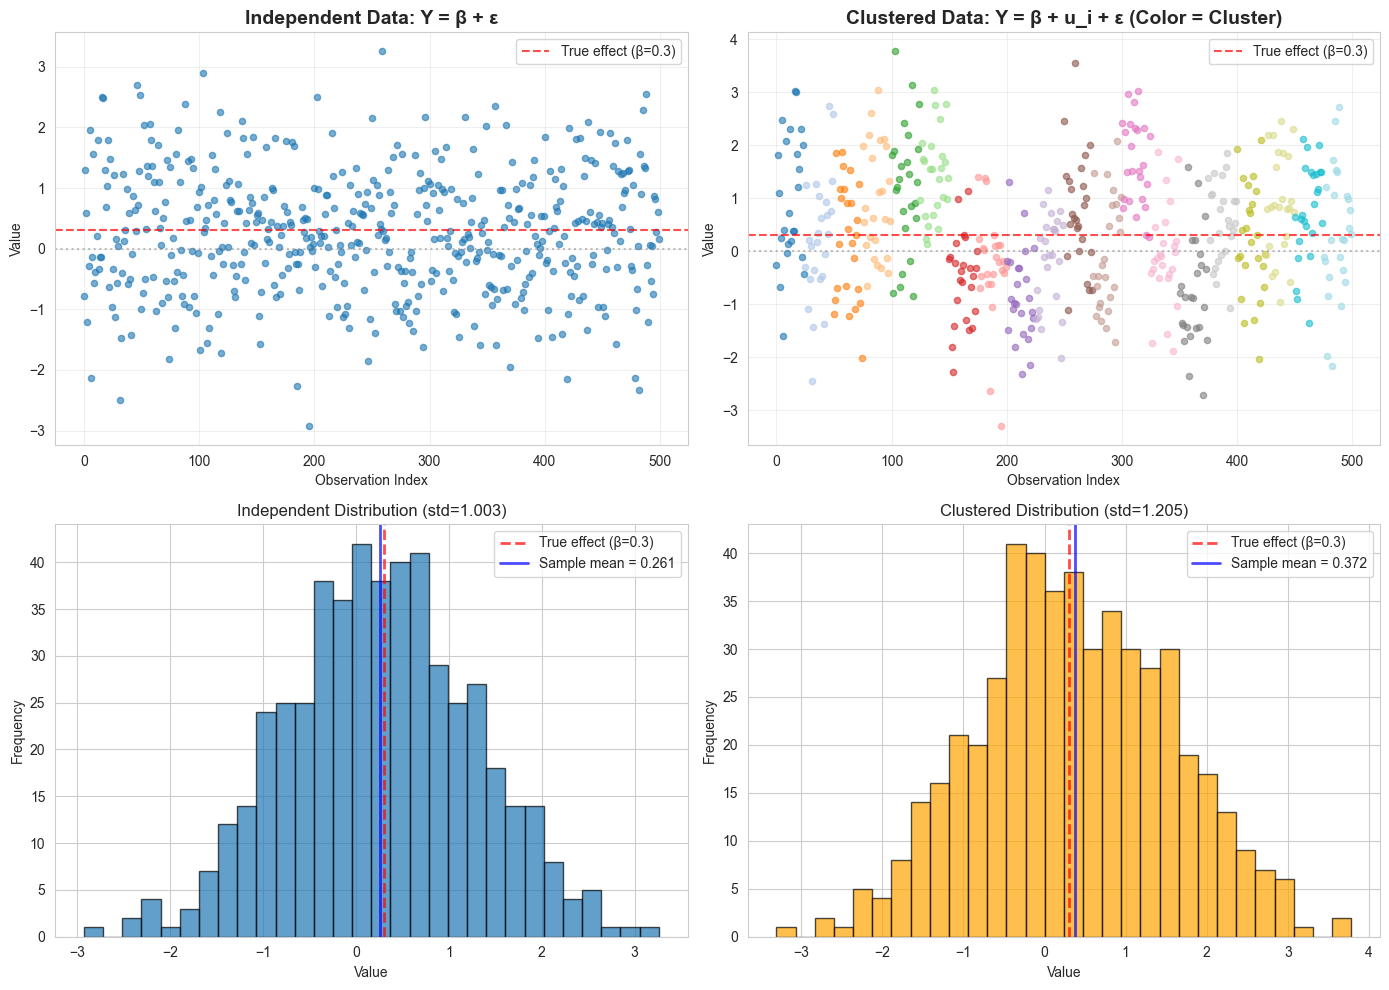

True effect (β): 0.3
Random intercept std (τ): 0.7
Noise std (σ): 1.0

Independent data - Mean: 0.2614, Std: 1.0032
Clustered data - Mean: 0.3718, Std: 1.2052

Both datasets have the SAME observation-level noise - only random intercepts differ.


In [4]:
# Generate paired sample data
n_clusters = 20
n_per_cluster = 25
n_total = n_clusters * n_per_cluster
true_effect = 0.3  # True signal
noise_std = 1.0
random_intercept_std = 0.7  # Between-cluster variability

independent_sample, clustered_sample, cluster_ids, random_intercepts = generate_paired_data(
    n_clusters=n_clusters, 
    n_per_cluster=n_per_cluster,
    true_effect=true_effect,
    noise_std=noise_std,
    random_intercept_std=random_intercept_std,
    seed=123
)

# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Independent data by observation index
axes[0, 0].scatter(range(len(independent_sample)), independent_sample, alpha=0.6, s=20)
axes[0, 0].axhline(y=true_effect, color='r', linestyle='--', alpha=0.7, label=f'True effect (β={true_effect})')
axes[0, 0].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0, 0].set_title('Independent Data: Y = β + ε', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Observation Index')
axes[0, 0].set_ylabel('Value')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Clustered data by cluster (color-coded)
colors = plt.cm.tab20(np.linspace(0, 1, n_clusters))
for i in range(n_clusters):
    mask = cluster_ids == i
    indices = np.where(mask)[0]
    axes[0, 1].scatter(indices, clustered_sample[mask], alpha=0.6, s=20, 
                      color=colors[i])
axes[0, 1].axhline(y=true_effect, color='r', linestyle='--', alpha=0.7, label=f'True effect (β={true_effect})')
axes[0, 1].axhline(y=0, color='gray', linestyle=':', alpha=0.5)
axes[0, 1].set_title('Clustered Data: Y = β + u_i + ε (Color = Cluster)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Observation Index')
axes[0, 1].set_ylabel('Value')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Histograms - Independent
axes[1, 0].hist(independent_sample, bins=30, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=true_effect, color='r', linestyle='--', alpha=0.7, linewidth=2, label=f'True effect (β={true_effect})')
axes[1, 0].axvline(x=np.mean(independent_sample), color='blue', linestyle='-', alpha=0.7, linewidth=2, label=f'Sample mean = {np.mean(independent_sample):.3f}')
axes[1, 0].set_title(f'Independent Distribution (std={np.std(independent_sample):.3f})', 
                     fontsize=12)
axes[1, 0].set_xlabel('Value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# Plot 4: Histograms - Clustered
axes[1, 1].hist(clustered_sample, bins=30, alpha=0.7, edgecolor='black', color='orange')
axes[1, 1].axvline(x=true_effect, color='r', linestyle='--', alpha=0.7, linewidth=2, label=f'True effect (β={true_effect})')
axes[1, 1].axvline(x=np.mean(clustered_sample), color='blue', linestyle='-', alpha=0.7, linewidth=2, label=f'Sample mean = {np.mean(clustered_sample):.3f}')
axes[1, 1].set_title(f'Clustered Distribution (std={np.std(clustered_sample):.3f})', 
                     fontsize=12)
axes[1, 1].set_xlabel('Value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print(f"True effect (β): {true_effect}")
print(f"Random intercept std (τ): {random_intercept_std}")
print(f"Noise std (σ): {noise_std}")
print(f"\nIndependent data - Mean: {np.mean(independent_sample):.4f}, Std: {np.std(independent_sample):.4f}")
print(f"Clustered data - Mean: {np.mean(clustered_sample):.4f}, Std: {np.std(clustered_sample):.4f}")
print(f"\nBoth datasets have the SAME observation-level noise - only random intercepts differ.")

## 3. Cluster Structure Analysis

Let's visualize the cluster means and random intercepts to see the between-cluster variation in effect sizes.

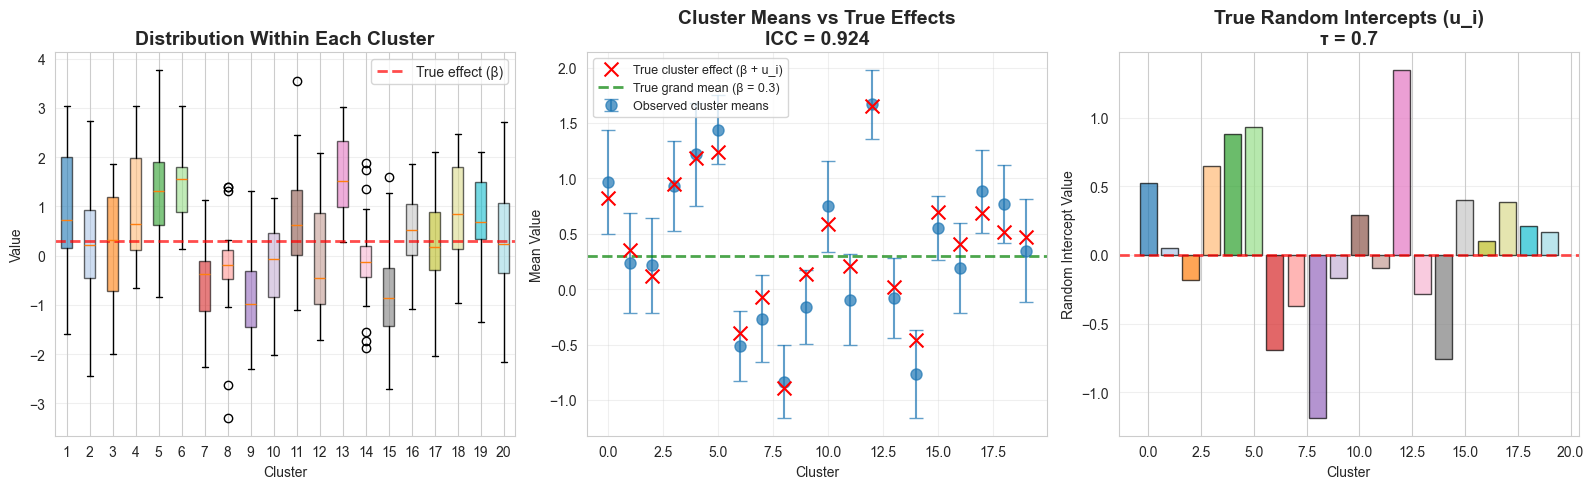


Cluster Structure Analysis:
True effect (β): 0.3
Random intercept std (τ): 0.7
Noise std (σ): 1.0
Theoretical ICC: τ²/(τ²+σ²) = 0.329
Estimated ICC: 0.924

Random intercepts range: [-1.191, 1.352]
Random intercepts std: 0.600 (true τ = 0.7)


In [5]:
# Calculate cluster means
cluster_means = np.array([clustered_sample[cluster_ids == i].mean() 
                          for i in range(n_clusters)])

# Calculate ICC from data
estimated_icc = calculate_icc(clustered_sample, cluster_ids)

# Theoretical ICC: τ² / (τ² + σ²)
theoretical_icc = random_intercept_std**2 / (random_intercept_std**2 + noise_std**2)

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Box plot by cluster
cluster_data_list = [clustered_sample[cluster_ids == i] for i in range(n_clusters)]
bp = axes[0].boxplot(cluster_data_list, patch_artist=True)
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[0].axhline(y=true_effect, color='r', linestyle='--', alpha=0.7, linewidth=2, label='True effect (β)')
axes[0].set_title('Distribution Within Each Cluster', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Cluster')
axes[0].set_ylabel('Value')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Plot 2: Cluster means with true random intercepts
cluster_sems = np.array([clustered_sample[cluster_ids == i].std() / np.sqrt(n_per_cluster) 
                         for i in range(n_clusters)])
axes[1].errorbar(range(n_clusters), cluster_means, yerr=cluster_sems * 1.96, 
                fmt='o', markersize=8, capsize=5, alpha=0.7, label='Observed cluster means')
axes[1].scatter(range(n_clusters), true_effect + random_intercepts, marker='x', s=100, 
                color='red', zorder=5, label='True cluster effect (β + u_i)')
axes[1].axhline(y=true_effect, color='green', linestyle='--', alpha=0.7, linewidth=2, 
                label=f'True grand mean (β = {true_effect})')
axes[1].set_title(f'Cluster Means vs True Effects\nICC = {estimated_icc:.3f}', 
                 fontsize=14, fontweight='bold')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Mean Value')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3: Random intercepts distribution
axes[2].bar(range(n_clusters), random_intercepts, color=colors, alpha=0.7, edgecolor='black')
axes[2].axhline(y=0, color='r', linestyle='--', alpha=0.7, linewidth=2)
axes[2].set_title(f'True Random Intercepts (u_i)\nτ = {random_intercept_std}', 
                 fontsize=14, fontweight='bold')
axes[2].set_xlabel('Cluster')
axes[2].set_ylabel('Random Intercept Value')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print(f"\nCluster Structure Analysis:")
print(f"True effect (β): {true_effect}")
print(f"Random intercept std (τ): {random_intercept_std}")
print(f"Noise std (σ): {noise_std}")
print(f"Theoretical ICC: τ²/(τ²+σ²) = {theoretical_icc:.3f}")
print(f"Estimated ICC: {estimated_icc:.3f}")
print(f"\nRandom intercepts range: [{random_intercepts.min():.3f}, {random_intercepts.max():.3f}]")
print(f"Random intercepts std: {random_intercepts.std():.3f} (true τ = {random_intercept_std})")

## 4. Statistical Testing

Now we'll perform simulations to compare statistical methods. Both datasets have:
- The same true fixed effect (β)
- The same observation-level noise

We'll test whether the fixed effect is significantly different from zero using:
1. **OLS on independent data**: Should work correctly since independence holds
2. **OLS on clustered data (naive/wrong)**: Ignores clustering - will show incorrect inference
3. **Cluster-robust standard errors**: Corrects for clustering using sandwich estimator
4. **Fixed effects model**: Includes cluster dummies to absorb group-level variation (common in economics)
5. **Mixed effects model (lmerTest)**: Uses R's lmerTest with Satterthwaite degrees of freedom approximation for proper small-sample inference

**Note on mixed effects implementations**: Python's statsmodels uses asymptotic (z-based) inference which can be anti-conservative with small numbers of clusters. R's lmerTest provides Satterthwaite df correction which gives more accurate Type I error control.

In [6]:
def cluster_robust_inference(y, X, cluster_ids):
    """
    OLS with cluster-robust standard errors (sandwich estimator).
    """
    # Fit OLS
    ols_result = OLS(y, X).fit()
    
    # Get cluster-robust covariance matrix
    cov_robust = cov_cluster(ols_result, cluster_ids)
    
    # Compute robust standard errors and test statistics
    se_robust = np.sqrt(np.diag(cov_robust))
    t_stats = ols_result.params / se_robust
    
    # Degrees of freedom: number of clusters - number of parameters
    n_clusters = len(np.unique(cluster_ids))
    df = n_clusters - len(ols_result.params)
    
    # Two-sided p-values with cluster-adjusted df
    p_values = 2 * (1 - stats.t.cdf(np.abs(t_stats), df=df))
    
    return {
        'params': ols_result.params,
        'se': se_robust,
        't_stats': t_stats,
        'p_values': p_values,
        'n_clusters': n_clusters,
        'df': df
    }


def fixed_effects_test(y, cluster_ids):
    """
    Fixed effects model with cluster dummies.
    This absorbs all cluster-level variation with dummy variables.
    Common approach in economics (within-group estimator).
    
    Note: For testing the intercept, we demean within clusters and test
    whether the overall mean differs from zero.
    """
    n = len(y)
    n_clusters = len(np.unique(cluster_ids))
    
    # Create cluster dummies (drop first for identification)
    cluster_dummies = pd.get_dummies(cluster_ids, drop_first=False)
    X = cluster_dummies.values
    
    # Fit OLS with cluster fixed effects
    model = OLS(y, X)
    result = model.fit()
    
    # The coefficients are the cluster means
    # Test if the average cluster effect differs from zero
    cluster_effects = result.params
    
    # Use F-test for joint significance of all cluster effects
    # Or equivalently, test if mean of cluster effects differs from zero
    mean_effect = np.mean(cluster_effects)
    se_mean = np.std(cluster_effects, ddof=1) / np.sqrt(n_clusters)
    t_stat = mean_effect / se_mean
    df = n_clusters - 1
    p_value = 2 * (1 - stats.t.cdf(np.abs(t_stat), df=df))
    
    return {
        'params': mean_effect,
        'se': se_mean,
        't_stats': t_stat,
        'p_values': p_value,
        'cluster_effects': cluster_effects,
        'df': df
    }


def mixed_effects_test_python(y, cluster_ids):
    """
    Random intercept model using statsmodels MixedLM.
    Tests if the overall mean is significantly different from zero.
    
    Note: Python's statsmodels uses asymptotic (z-based) inference which
    can be anti-conservative with small numbers of clusters. For proper
    degrees of freedom correction, use mixed_effects_test_r() with lmerTest.
    """
    from statsmodels.regression.mixed_linear_model import MixedLM
    
    n = len(y)
    X = np.ones((n, 1))  # Just intercept
    
    # Fit mixed effects model with random intercepts
    model = MixedLM(y, X, groups=cluster_ids)
    
    # Try fitting with different methods
    result = None
    methods = ['bfgs', 'powell', 'lbfgs']
    
    for method in methods:
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = model.fit(method=method, maxiter=500, reml=True)
                if result.converged:
                    break
        except Exception:
            continue
    
    if result is None:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            result = model.fit(method='powell', maxiter=1000, reml=True)
    
    # Extract random effects variance safely
    try:
        if hasattr(result.cov_re, 'values'):
            re_var = result.cov_re.values[0, 0]
        elif hasattr(result.cov_re, '__getitem__'):
            re_var = result.cov_re[0, 0]
        else:
            re_var = float(result.cov_re)
    except Exception:
        re_var = np.nan
    
    return {
        'params': result.params,
        'se': result.bse,
        't_stats': result.tvalues,
        'p_values': result.pvalues,
        'random_effects_var': re_var,
        'converged': result.converged
    }


def mixed_effects_test_r(y, cluster_ids):
    """
    Random intercept model using R's lmerTest package.
    Uses Satterthwaite degrees of freedom approximation for proper
    small-sample inference.
    
    This provides more accurate p-values than Python's statsmodels,
    especially with small numbers of clusters.
    
    Model: y ~ 1 + (1|cluster)
    Tests H0: intercept = 0 (i.e., the overall mean is zero)
    
    Parameters:
    -----------
    y : array-like
        Response variable
    cluster_ids : array-like
        Cluster membership indicators
    """
    # Create pandas DataFrame
    df = pd.DataFrame({
        'y': y,
        'cluster': cluster_ids.astype(str)
    })
    
    # Convert to R data frame using localconverter context manager
    with localconverter(ro.default_converter + pandas2ri.converter):
        r_df = ro.conversion.py2rpy(df)
    
    # Assign to R environment
    ro.globalenv['data'] = r_df
    
    # Fit model using lmerTest (which extends lme4)
    # lmerTest::lmer automatically provides Satterthwaite df
    ro.r('''
        suppressMessages({
            library(lmerTest)
            model <- lmer(y ~ 1 + (1|cluster), data=data, REML=TRUE)
            coef_table <- summary(model)$coefficients
        })
    ''')
    
    # Extract results - convert R matrix to numpy array first
    coef_table = np.array(ro.r('coef_table'))
    
    # lmerTest coefficient table columns: Estimate, Std. Error, df, t value, Pr(>|t|)
    # Row 0 is the intercept
    estimate = coef_table[0, 0]
    se = coef_table[0, 1]
    df = coef_table[0, 2]
    t_stat = coef_table[0, 3]
    p_value = coef_table[0, 4]
    
    # Get random effects variance
    re_var = ro.r('as.numeric(VarCorr(model)$cluster[1])')[0]
    
    return {
        'params': np.array([estimate]),
        'se': np.array([se]),
        't_stats': np.array([t_stat]),
        'p_values': np.array([p_value]),
        'df': df,
        'random_effects_var': re_var
    }


def run_simulation(n_simulations=1000, n_clusters=20, n_per_cluster=10, 
                   true_effect=0.0, noise_std=1.0, random_intercept_std=0.5, 
                   alpha=0.05, seed=None):
    """
    Run multiple simulations to assess Type I error rates (when true_effect=0)
    or power (when true_effect != 0).
    
    Compares naive OLS, cluster-robust SE, fixed effects, and mixed effects
    using both Python (statsmodels) and R (lmerTest).
    
    The simulation tests whether the mean of y differs from 0, where
    y = true_effect + random_intercept + noise.
    """
    if seed is not None:
        np.random.seed(seed)
    
    n_samples = n_clusters * n_per_cluster
    
    # Store p-values from all simulations
    p_values_independent = []
    p_values_clustered_naive = []
    p_values_clustered_robust = []
    p_values_clustered_fe = []
    p_values_clustered_mixed_python = []
    p_values_clustered_mixed_r = []
    
    for i in range(n_simulations):
        # Generate paired data
        independent_data, clustered_data, cluster_ids, _ = generate_paired_data(
            n_clusters=n_clusters,
            n_per_cluster=n_per_cluster,
            true_effect=true_effect,
            noise_std=noise_std,
            random_intercept_std=random_intercept_std
        )
        
        # Test 1: Standard t-test on independent data
        t_stat, p_val = stats.ttest_1samp(independent_data, 0)
        p_values_independent.append(p_val)
        
        # Test 2: Naive OLS on clustered data (WRONG - ignores clustering)
        t_stat, p_val = stats.ttest_1samp(clustered_data, 0)
        p_values_clustered_naive.append(p_val)
        
        # Test 3: Cluster-robust standard errors
        try:
            X = np.ones((n_samples, 1))
            y = clustered_data
            result = cluster_robust_inference(y, X, cluster_ids)
            p_values_clustered_robust.append(result['p_values'][0])
        except Exception:
            p_values_clustered_robust.append(np.nan)
        
        # Test 4: Fixed effects model
        try:
            result = fixed_effects_test(clustered_data, cluster_ids)
            p_values_clustered_fe.append(result['p_values'])
        except Exception:
            p_values_clustered_fe.append(np.nan)
        
        # Test 5: Mixed effects model - Python (statsmodels)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = mixed_effects_test_python(clustered_data, cluster_ids)
                p_values_clustered_mixed_python.append(result['p_values'][0])
        except Exception:
            p_values_clustered_mixed_python.append(np.nan)
        
        # Test 6: Mixed effects model - R (lmerTest)
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                result = mixed_effects_test_r(clustered_data, cluster_ids)
                p_values_clustered_mixed_r.append(result['p_values'][0])
        except Exception as e:
            p_values_clustered_mixed_r.append(np.nan)
    
    # Remove any NaN values
    p_values_clustered_robust = np.array([p for p in p_values_clustered_robust if not np.isnan(p)])
    p_values_clustered_fe = np.array([p for p in p_values_clustered_fe if not np.isnan(p)])
    p_values_clustered_mixed_python = np.array([p for p in p_values_clustered_mixed_python if not np.isnan(p)])
    p_values_clustered_mixed_r = np.array([p for p in p_values_clustered_mixed_r if not np.isnan(p)])
    
    # Calculate Type I error rates (or power if true_effect != 0)
    rejection_independent = np.mean(np.array(p_values_independent) < alpha)
    rejection_clustered_naive = np.mean(np.array(p_values_clustered_naive) < alpha)
    rejection_clustered_robust = np.mean(p_values_clustered_robust < alpha) if len(p_values_clustered_robust) > 0 else np.nan
    rejection_clustered_fe = np.mean(p_values_clustered_fe < alpha) if len(p_values_clustered_fe) > 0 else np.nan
    rejection_clustered_mixed_python = np.mean(p_values_clustered_mixed_python < alpha) if len(p_values_clustered_mixed_python) > 0 else np.nan
    rejection_clustered_mixed_r = np.mean(p_values_clustered_mixed_r < alpha) if len(p_values_clustered_mixed_r) > 0 else np.nan
    
    results = {
        'p_values_independent': np.array(p_values_independent),
        'p_values_clustered_naive': np.array(p_values_clustered_naive),
        'p_values_clustered_robust': p_values_clustered_robust,
        'p_values_clustered_fe': p_values_clustered_fe,
        'p_values_clustered_mixed_python': p_values_clustered_mixed_python,
        'p_values_clustered_mixed_r': p_values_clustered_mixed_r,
        'rejection_independent': rejection_independent,
        'rejection_clustered_naive': rejection_clustered_naive,
        'rejection_clustered_robust': rejection_clustered_robust,
        'rejection_clustered_fe': rejection_clustered_fe,
        'rejection_clustered_mixed_python': rejection_clustered_mixed_python,
        'rejection_clustered_mixed_r': rejection_clustered_mixed_r,
    }
    
    return results

## 5. Run Simulations and Analyze Results

In [7]:
# Run simulations under the null hypothesis (true_effect = 0)
print("Running simulations under null hypothesis (no true effect)...")
results = run_simulation(n_simulations=1000, n_clusters=20, n_per_cluster=10,
                        true_effect=0.0, noise_std=1.0, random_intercept_std=0.7,
                        alpha=0.05, seed=42)

print("\n" + "="*80)
print("RESULTS: Type I Error Rates (False Positive Rates)")
print("="*80)
print(f"Expected Type I error rate (α): 5.00%")
print()
print(f"1. OLS on independent data (correct baseline):    {results['rejection_independent']*100:.2f}%")
print(f"2. Naive OLS on clustered data (WRONG):          {results['rejection_clustered_naive']*100:.2f}%")
print(f"3. Cluster-robust standard errors:               {results['rejection_clustered_robust']*100:.2f}%")
print(f"4. Fixed effects model:                          {results['rejection_clustered_fe']*100:.2f}%")
print(f"5. Mixed effects - Python (asymptotic):          {results['rejection_clustered_mixed_python']*100:.2f}%")
print(f"6. Mixed effects - R/lmerTest (Satterthwaite):   {results['rejection_clustered_mixed_r']*100:.2f}%")
print()
print(f"Naive OLS inflation factor: {results['rejection_clustered_naive']/max(results['rejection_independent'], 0.01):.2f}x")
print("="*80)

Running simulations under null hypothesis (no true effect)...

RESULTS: Type I Error Rates (False Positive Rates)
Expected Type I error rate (α): 5.00%

1. OLS on independent data (correct baseline):    5.50%
2. Naive OLS on clustered data (WRONG):          31.80%
3. Cluster-robust standard errors:               4.80%
4. Fixed effects model:                          4.80%
5. Mixed effects - Python (asymptotic):          6.30%
6. Mixed effects - R/lmerTest (Satterthwaite):   4.80%

Naive OLS inflation factor: 5.78x


## 6. Visualize P-value Distributions

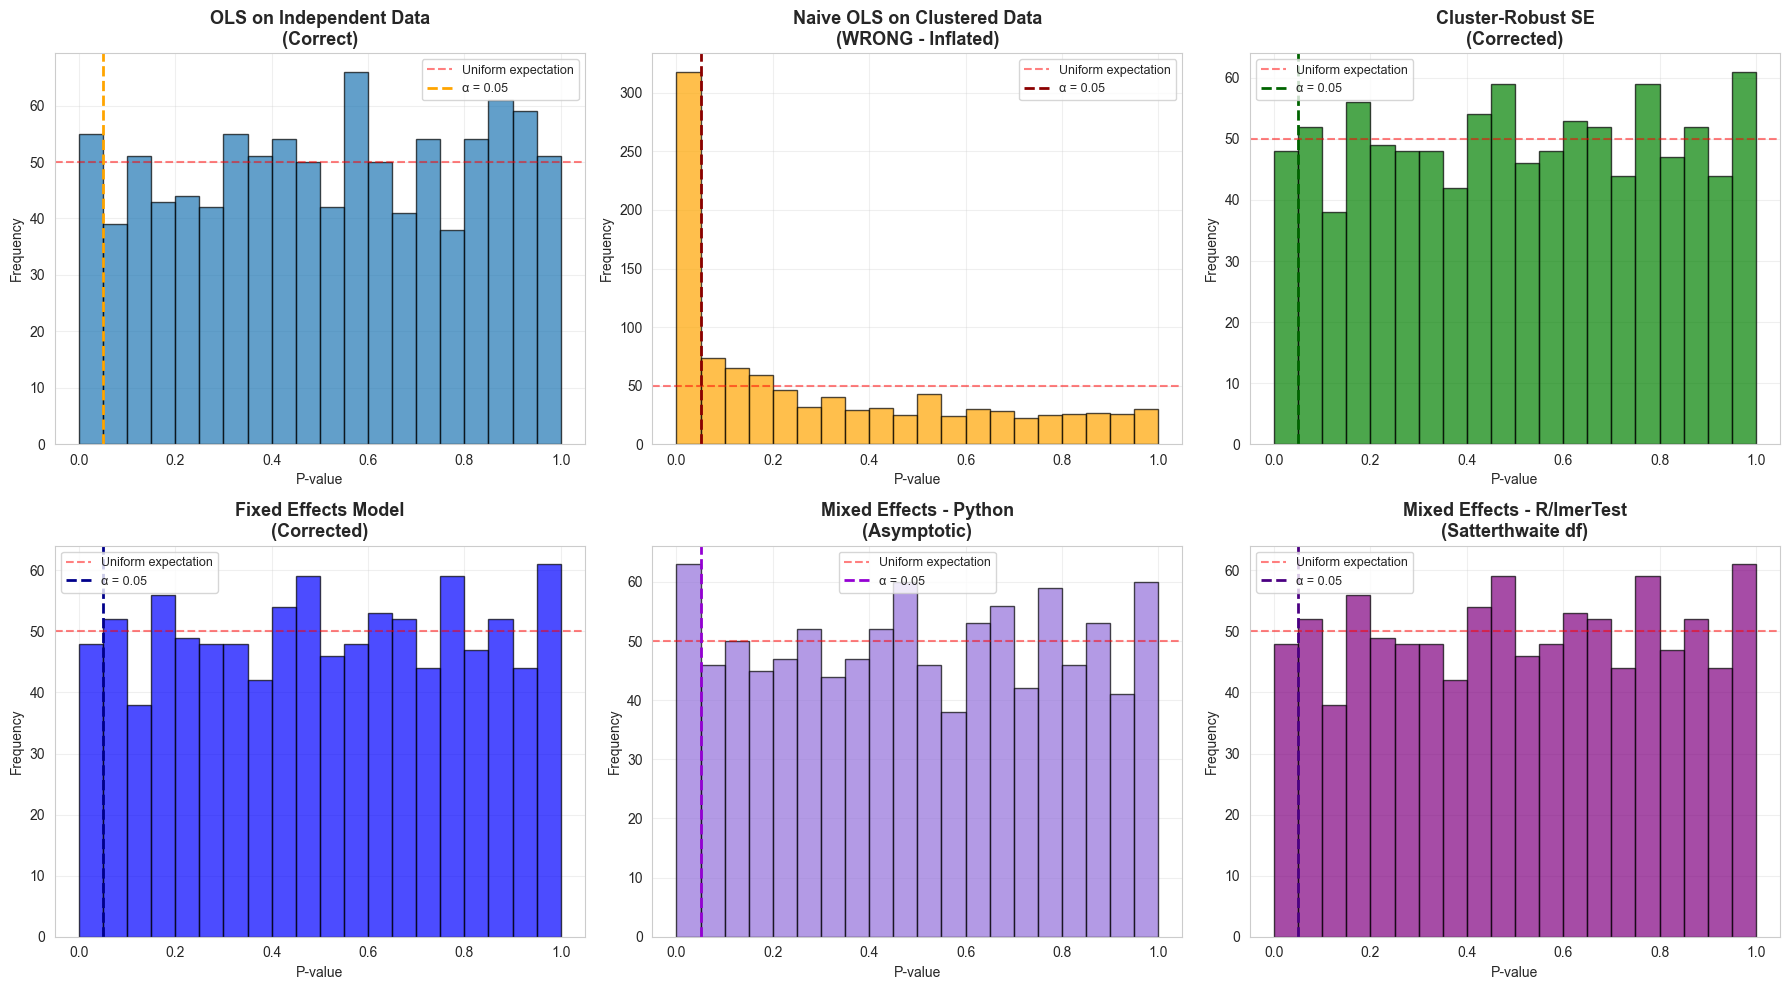

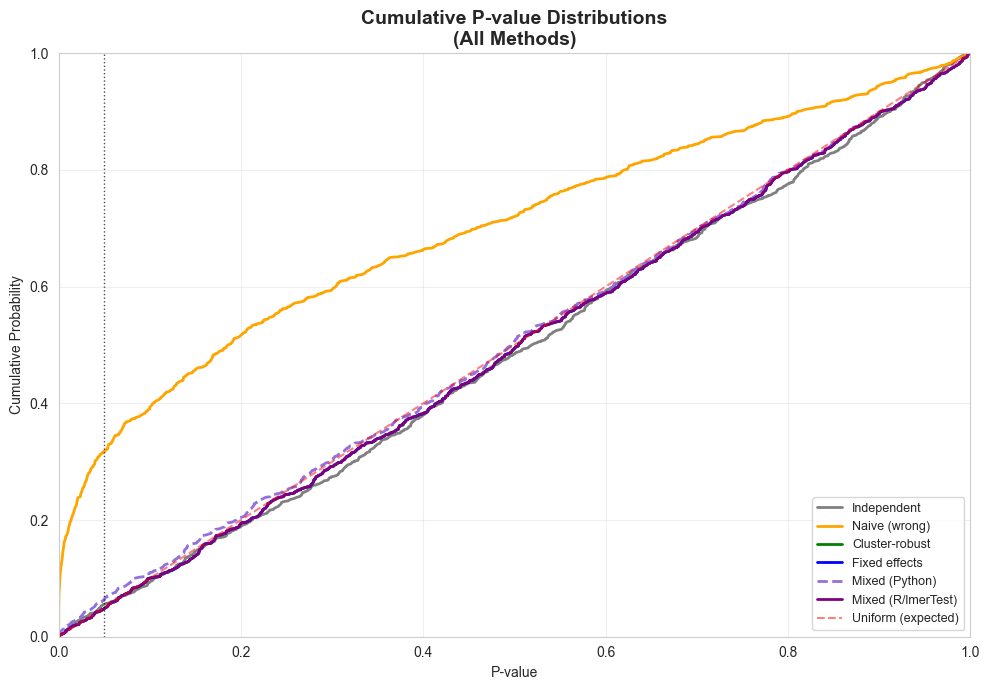

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# P-value histograms
axes[0, 0].hist(results['p_values_independent'], bins=20, alpha=0.7, edgecolor='black', 
                range=(0, 1))
axes[0, 0].axhline(y=len(results['p_values_independent'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[0, 0].axvline(x=0.05, color='orange', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[0, 0].set_title('OLS on Independent Data\n(Correct)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('P-value')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].legend(fontsize=9)
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].hist(results['p_values_clustered_naive'], bins=20, alpha=0.7, edgecolor='black', 
                color='orange', range=(0, 1))
axes[0, 1].axhline(y=len(results['p_values_clustered_naive'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[0, 1].axvline(x=0.05, color='darkred', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[0, 1].set_title('Naive OLS on Clustered Data\n(WRONG - Inflated)', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('P-value')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(fontsize=9)
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].hist(results['p_values_clustered_robust'], bins=20, alpha=0.7, edgecolor='black', 
                color='green', range=(0, 1))
axes[0, 2].axhline(y=len(results['p_values_clustered_robust'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[0, 2].axvline(x=0.05, color='darkgreen', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[0, 2].set_title('Cluster-Robust SE\n(Corrected)', fontsize=13, fontweight='bold')
axes[0, 2].set_xlabel('P-value')
axes[0, 2].set_ylabel('Frequency')
axes[0, 2].legend(fontsize=9)
axes[0, 2].grid(True, alpha=0.3)

# Second row: Fixed effects, Mixed effects Python, Mixed effects R
axes[1, 0].hist(results['p_values_clustered_fe'], bins=20, alpha=0.7, edgecolor='black', 
                color='blue', range=(0, 1))
axes[1, 0].axhline(y=len(results['p_values_clustered_fe'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[1, 0].axvline(x=0.05, color='darkblue', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[1, 0].set_title('Fixed Effects Model\n(Corrected)', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('P-value')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend(fontsize=9)
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].hist(results['p_values_clustered_mixed_python'], bins=20, alpha=0.7, edgecolor='black', 
                color='mediumpurple', range=(0, 1))
axes[1, 1].axhline(y=len(results['p_values_clustered_mixed_python'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[1, 1].axvline(x=0.05, color='darkviolet', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[1, 1].set_title('Mixed Effects - Python\n(Asymptotic)', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('P-value')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].hist(results['p_values_clustered_mixed_r'], bins=20, alpha=0.7, edgecolor='black', 
                color='purple', range=(0, 1))
axes[1, 2].axhline(y=len(results['p_values_clustered_mixed_r'])/20, color='r', linestyle='--', 
                   alpha=0.5, label='Uniform expectation')
axes[1, 2].axvline(x=0.05, color='indigo', linestyle='--', linewidth=2, 
                   label='α = 0.05')
axes[1, 2].set_title('Mixed Effects - R/lmerTest\n(Satterthwaite df)', fontsize=13, fontweight='bold')
axes[1, 2].set_xlabel('P-value')
axes[1, 2].set_ylabel('Frequency')
axes[1, 2].legend(fontsize=9)
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Cumulative comparison plot
fig2, ax = plt.subplots(figsize=(10, 7))

sorted_p_ind = np.sort(results['p_values_independent'])
sorted_p_naive = np.sort(results['p_values_clustered_naive'])
sorted_p_robust = np.sort(results['p_values_clustered_robust'])
sorted_p_fe = np.sort(results['p_values_clustered_fe'])
sorted_p_mixed_py = np.sort(results['p_values_clustered_mixed_python'])
sorted_p_mixed_r = np.sort(results['p_values_clustered_mixed_r'])

cumulative_ind = np.arange(1, len(sorted_p_ind) + 1) / len(sorted_p_ind)
cumulative_naive = np.arange(1, len(sorted_p_naive) + 1) / len(sorted_p_naive)
cumulative_robust = np.arange(1, len(sorted_p_robust) + 1) / len(sorted_p_robust)
cumulative_fe = np.arange(1, len(sorted_p_fe) + 1) / len(sorted_p_fe)
cumulative_mixed_py = np.arange(1, len(sorted_p_mixed_py) + 1) / len(sorted_p_mixed_py)
cumulative_mixed_r = np.arange(1, len(sorted_p_mixed_r) + 1) / len(sorted_p_mixed_r)

ax.plot(sorted_p_ind, cumulative_ind, linewidth=2, label='Independent', color='gray')
ax.plot(sorted_p_naive, cumulative_naive, linewidth=2, color='orange', label='Naive (wrong)')
ax.plot(sorted_p_robust, cumulative_robust, linewidth=2, color='green', label='Cluster-robust')
ax.plot(sorted_p_fe, cumulative_fe, linewidth=2, color='blue', label='Fixed effects')
ax.plot(sorted_p_mixed_py, cumulative_mixed_py, linewidth=2, color='mediumpurple', 
        label='Mixed (Python)', linestyle='--')
ax.plot(sorted_p_mixed_r, cumulative_mixed_r, linewidth=2, color='purple', label='Mixed (R/lmerTest)')
ax.plot([0, 1], [0, 1], 'r--', alpha=0.5, label='Uniform (expected)')
ax.axvline(x=0.05, color='black', linestyle=':', linewidth=1, alpha=0.7)
ax.set_title('Cumulative P-value Distributions\n(All Methods)', fontsize=14, fontweight='bold')
ax.set_xlabel('P-value')
ax.set_ylabel('Cumulative Probability')
ax.legend(fontsize=9, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.show()

## 7. Effect of Clustering Strength (Random Intercept Variance)

Let's examine how different levels of between-cluster variability affect Type I error rates. Higher random intercept variance means stronger clustering.

**Note on convergence**: Mixed effects models can have convergence issues when the random effects variance is very small (near zero). This is a "boundary problem" - the variance parameter cannot be negative, so estimation near zero is constrained. The results are still valid; warnings are suppressed for cleaner output.

Testing different clustering strengths (random intercept std)...
Note: Convergence issues may occur with very low τ - results still valid.

τ = 0.1 (ICC = 0.01) -> Naive: 6.6%, Robust: 3.8%, FE: 3.8%, Mixed(Py): 4.8%, Mixed(R): 3.6%
τ = 0.2 (ICC = 0.04) -> Naive: 9.4%, Robust: 6.0%, FE: 6.0%, Mixed(Py): 6.0%, Mixed(R): 5.2%
τ = 0.4 (ICC = 0.14) -> Naive: 19.4%, Robust: 6.0%, FE: 6.0%, Mixed(Py): 7.6%, Mixed(R): 6.0%
τ = 0.6 (ICC = 0.26) -> Naive: 28.6%, Robust: 5.6%, FE: 5.6%, Mixed(Py): 6.6%, Mixed(R): 5.6%
τ = 0.8 (ICC = 0.39) -> Naive: 39.8%, Robust: 6.0%, FE: 6.0%, Mixed(Py): 7.4%, Mixed(R): 6.0%
τ = 1.0 (ICC = 0.50) -> Naive: 45.0%, Robust: 6.0%, FE: 6.0%, Mixed(Py): 7.8%, Mixed(R): 6.0%
τ = 1.2 (ICC = 0.59) -> Naive: 46.8%, Robust: 5.6%, FE: 5.6%, Mixed(Py): 6.8%, Mixed(R): 5.6%
τ = 1.5 (ICC = 0.69) -> Naive: 51.2%, Robust: 5.2%, FE: 5.2%, Mixed(Py): 6.6%, Mixed(R): 5.2%


/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_41492/4214509513.py:44: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "x-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[0].plot(random_intercept_stds, type1_errors_mixed_python, 'x-', linewidth=2, markersize=7,
/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_41492/4214509513.py:65: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "x-" (-> linestyle='-'). The keyword argument will take precedence.
  axes[1].plot(icc_levels, type1_errors_mixed_python, 'x-', linewidth=2, markersize=7,


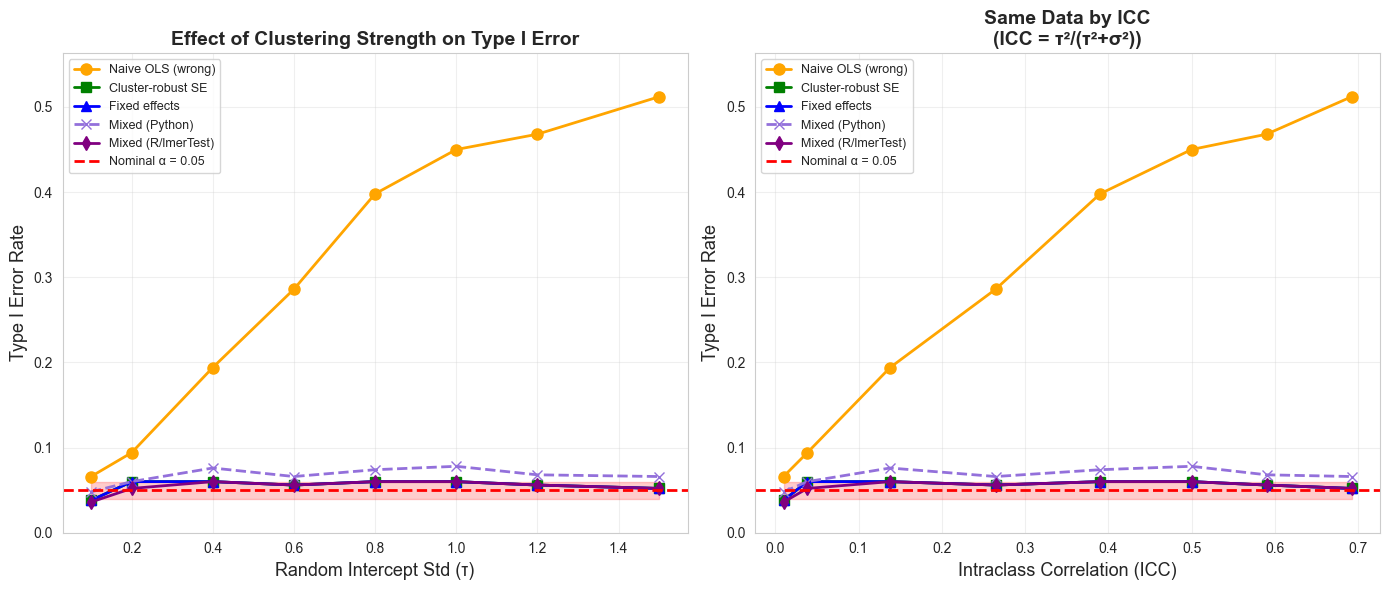

In [9]:
# Test different random intercept std levels (which determines ICC)
# ICC = τ² / (τ² + σ²), so τ = σ * sqrt(ICC / (1 - ICC))
# Note: We start from τ = 0.1 instead of 0 because mixed effects models
# have convergence issues at the boundary (τ = 0)
noise_std = 1.0
random_intercept_stds = [0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.5]
icc_levels = [tau**2 / (tau**2 + noise_std**2) for tau in random_intercept_stds]

type1_errors_naive = []
type1_errors_robust = []
type1_errors_fe = []
type1_errors_mixed_python = []
type1_errors_mixed_r = []

print("Testing different clustering strengths (random intercept std)...")
print("Note: Convergence issues may occur with very low τ - results still valid.\n")

for tau in random_intercept_stds:
    icc = tau**2 / (tau**2 + noise_std**2) if tau > 0 else 0
    result = run_simulation(n_simulations=500, n_clusters=20, n_per_cluster=10,
                          true_effect=0.0, noise_std=noise_std, 
                          random_intercept_std=tau, alpha=0.05)
    type1_errors_naive.append(result['rejection_clustered_naive'])
    type1_errors_robust.append(result['rejection_clustered_robust'])
    type1_errors_fe.append(result['rejection_clustered_fe'])
    type1_errors_mixed_python.append(result['rejection_clustered_mixed_python'])
    type1_errors_mixed_r.append(result['rejection_clustered_mixed_r'])
    print(f"τ = {tau:.1f} (ICC = {icc:.2f}) -> Naive: {result['rejection_clustered_naive']*100:.1f}%, "
          f"Robust: {result['rejection_clustered_robust']*100:.1f}%, "
          f"FE: {result['rejection_clustered_fe']*100:.1f}%, "
          f"Mixed(Py): {result['rejection_clustered_mixed_python']*100:.1f}%, "
          f"Mixed(R): {result['rejection_clustered_mixed_r']*100:.1f}%")


/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_41492/4211484817.py:10: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "x-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(random_intercept_stds, type1_errors_mixed_python, 'x-', linewidth=2, markersize=7,


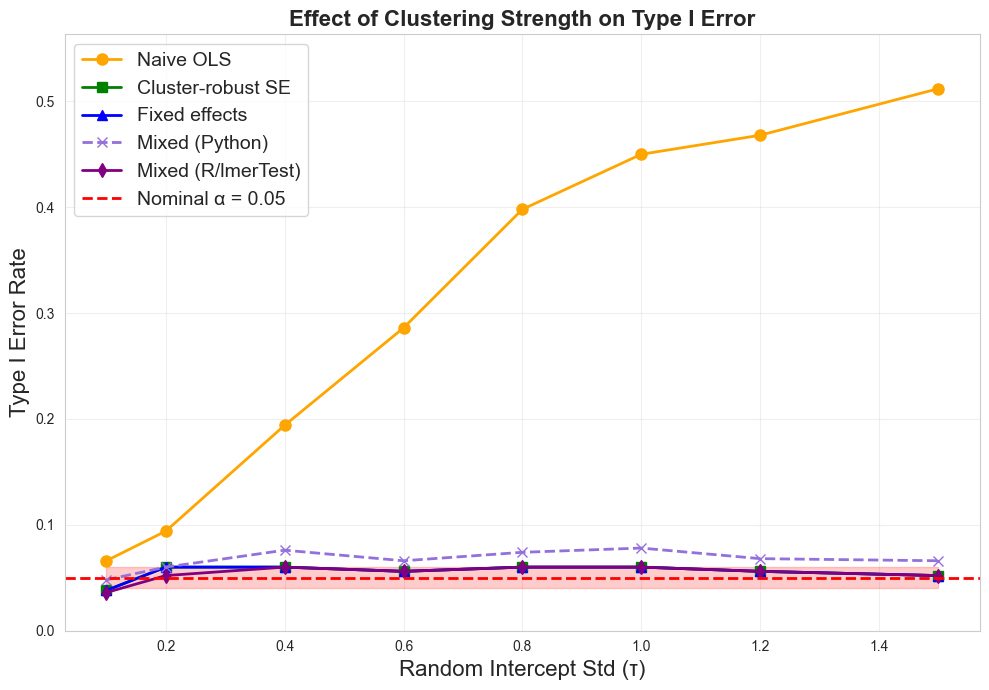

In [19]:

# Plot results
plt.figure(figsize=(10, 7))

plt.plot(random_intercept_stds, type1_errors_naive, 'o-', linewidth=2, markersize=8, 
         color='orange', label='Naive OLS')
plt.plot(random_intercept_stds, type1_errors_robust, 's-', linewidth=2, markersize=7, 
         color='green', label='Cluster-robust SE')
plt.plot(random_intercept_stds, type1_errors_fe, '^-', linewidth=2, markersize=7, 
         color='blue', label='Fixed effects')
plt.plot(random_intercept_stds, type1_errors_mixed_python, 'x-', linewidth=2, markersize=7, 
         color='mediumpurple', label='Mixed (Python)', linestyle='--')
plt.plot(random_intercept_stds, type1_errors_mixed_r, 'd-', linewidth=2, markersize=7, 
         color='purple', label='Mixed (R/lmerTest)')
plt.axhline(y=0.05, color='r', linestyle='--', linewidth=2, label='Nominal α = 0.05')
plt.fill_between(random_intercept_stds, 0.04, 0.06, alpha=0.2, color='red')
plt.xlabel('Random Intercept Std (τ)', fontsize=16)
plt.ylabel('Type I Error Rate', fontsize=16)
plt.title('Effect of Clustering Strength on Type I Error', 
          fontsize=16, fontweight='bold')
plt.legend(fontsize=14, loc='upper left')
plt.grid(True, alpha=0.3)
plt.ylim([0, max(type1_errors_naive) * 1.1])

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'type1_error_by_clustering_strength.png', dpi=300)
plt.show()

## 8. Effect of Number of Clusters

The number of clusters is critical for cluster-robust inference. Let's see how it affects performance.

In [14]:
# Test different numbers of clusters (keeping total n constant)
n_total = 200
cluster_counts = [5, 10, 20, 40, 50]
type1_errors_naive_nc = []
type1_errors_robust_nc = []
type1_errors_fe_nc = []
type1_errors_mixed_python_nc = []
type1_errors_mixed_r_nc = []

print("\nTesting different numbers of clusters...")
for n_clust in cluster_counts:
    n_per = n_total // n_clust
    result = run_simulation(n_simulations=500, n_clusters=n_clust, n_per_cluster=n_per,
                          true_effect=0.0, noise_std=1.0, random_intercept_std=0.7, 
                          alpha=0.05)
    type1_errors_naive_nc.append(result['rejection_clustered_naive'])
    type1_errors_robust_nc.append(result['rejection_clustered_robust'])
    type1_errors_fe_nc.append(result['rejection_clustered_fe'])
    type1_errors_mixed_python_nc.append(result['rejection_clustered_mixed_python'])
    type1_errors_mixed_r_nc.append(result['rejection_clustered_mixed_r'])
    print(f"N clusters: {n_clust} (n per cluster: {n_per}) -> "
          f"Naive: {result['rejection_clustered_naive']*100:.1f}%, "
          f"Robust: {result['rejection_clustered_robust']*100:.1f}%, "
          f"FE: {result['rejection_clustered_fe']*100:.1f}%, "
          f"Mixed(Py): {result['rejection_clustered_mixed_python']*100:.1f}%, "
          f"Mixed(R): {result['rejection_clustered_mixed_r']*100:.1f}%")




Testing different numbers of clusters...
N clusters: 5 (n per cluster: 40) -> Naive: 63.8%, Robust: 5.6%, FE: 5.6%, Mixed(Py): 13.0%, Mixed(R): 5.6%
N clusters: 10 (n per cluster: 20) -> Naive: 50.0%, Robust: 4.2%, FE: 4.2%, Mixed(Py): 7.6%, Mixed(R): 4.2%
N clusters: 20 (n per cluster: 10) -> Naive: 31.4%, Robust: 4.4%, FE: 4.4%, Mixed(Py): 6.4%, Mixed(R): 4.4%
N clusters: 40 (n per cluster: 5) -> Naive: 19.2%, Robust: 7.0%, FE: 7.0%, Mixed(Py): 8.2%, Mixed(R): 7.0%
N clusters: 50 (n per cluster: 4) -> Naive: 18.0%, Robust: 5.8%, FE: 5.8%, Mixed(Py): 6.4%, Mixed(R): 5.8%


/var/folders/r2/f85nyfr1785fj4257wkdj7480000gn/T/ipykernel_41492/282399972.py:9: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "x-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(cluster_counts, type1_errors_mixed_python_nc, 'x-', linewidth=2, markersize=7,


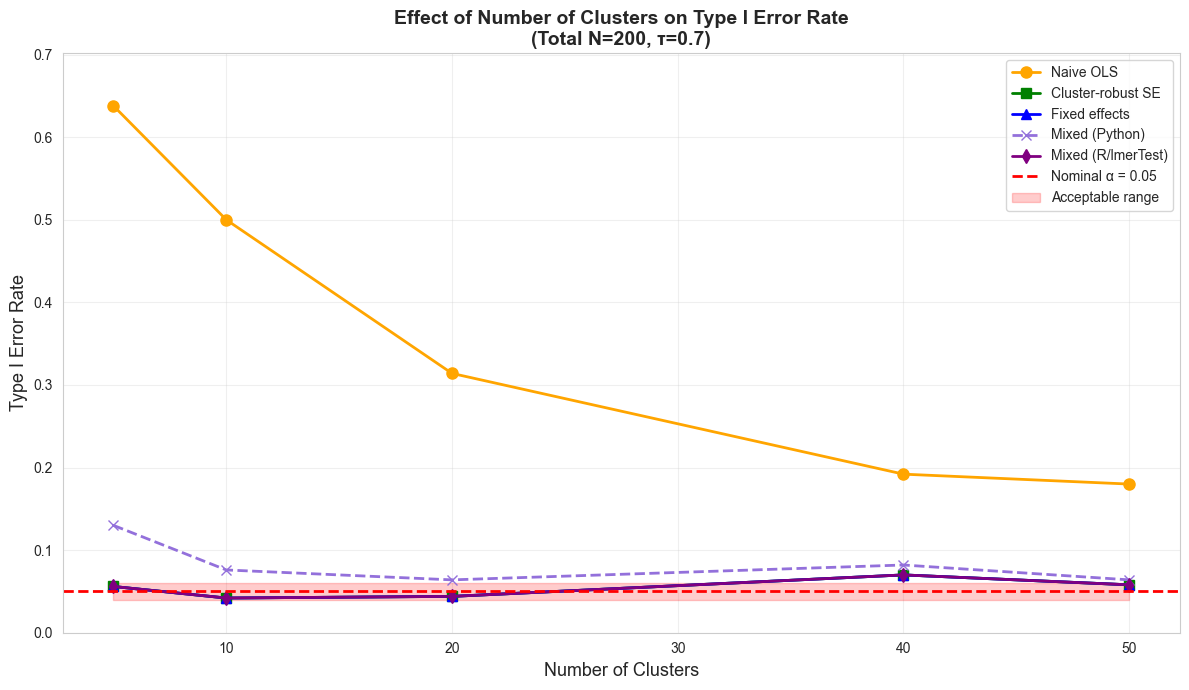

In [ ]:
# Plot results
plt.figure(figsize=(12, 7))
plt.plot(cluster_counts, type1_errors_naive_nc, 'o-', linewidth=2, markersize=8, 
         color='orange', label='Naive OLS')
plt.plot(cluster_counts, type1_errors_robust_nc, 's-', linewidth=2, markersize=7, 
         color='green', label='Cluster-robust SE')
plt.plot(cluster_counts, type1_errors_fe_nc, '^-', linewidth=2, markersize=7, 
         color='blue', label='Fixed effects')
plt.plot(cluster_counts, type1_errors_mixed_python_nc, 'x-', linewidth=2, markersize=7, 
         color='mediumpurple', label='Mixed (Python)', linestyle='--')
plt.plot(cluster_counts, type1_errors_mixed_r_nc, 'd-', linewidth=2, markersize=7, 
         color='purple', label='Mixed (R/lmerTest)')
plt.axhline(y=0.05, color='r', linestyle='--', linewidth=2, label='Nominal α = 0.05')
plt.fill_between(cluster_counts, 0.04, 0.06, alpha=0.2, color='red', 
                 label='Acceptable range')
plt.xlabel('Number of Clusters', fontsize=13)
plt.ylabel('Type I Error Rate', fontsize=13)
plt.title(f'Effect of Number of Clusters on Type I Error Rate\n(Total N={n_total}, τ=0.7)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3)
plt.ylim([0, max(type1_errors_naive_nc) * 1.1])

plt.tight_layout()
plt.show()

## 9. Summary and Interpretation

### Data Generation Model

In this notebook, we used paired datasets with:
- **Independent data**: Y = β + ε (true effect + observation noise)
- **Clustered data**: Y = β + u_i + ε (true effect + random intercept + same noise)

Both datasets share the same true effect (β) and the same observation-level noise (ε). The only difference is that clustered data has group-level variability (random intercepts u_i), representing true heterogeneity across clusters.

### Key Findings:

1. **Naive OLS on Clustered Data (WRONG)**: When clustering is ignored, standard OLS produces severely inflated Type I error rates. The inflation depends on:
   - **Random intercept variance (τ²)**: Higher τ → stronger clustering → more inflation
   - **Cluster size**: Larger clusters → more inflation
   - Can easily exceed 30-40% Type I error rates with moderate clustering!

2. **Cluster-Robust Standard Errors**: Uses sandwich estimator accounting for within-cluster correlation:
   - Adjusts degrees of freedom to number of clusters (not observations)
   - Works well when number of clusters is adequate (≥20-30)
   - Most commonly used correction in practice

3. **Fixed Effects Model**: Uses cluster dummy variables to absorb group-level variation:
   - Common approach in economics ("within-group estimator")
   - Eliminates bias from cluster-level confounders
   - Uses cluster means to test overall effect
   - Particularly useful when cluster effects may be correlated with treatment

4. **Mixed Effects Models**: Explicitly models cluster random effects:
   - Most efficient when model is correctly specified
   - Provides estimates of ICC and variance components
   - Assumes random intercepts are uncorrelated with fixed effects
   - **lmerTest (R)**: Uses Satterthwaite degrees of freedom approximation for proper Type I error control
   - **statsmodels (Python)**: Uses asymptotic (z-based) inference which can be anti-conservative with few clusters

### Why Clustering Matters:

**Design Effect**: With ICC = ρ and cluster size = n:
- Design effect ≈ 1 + (n - 1) × ρ
- Effective sample size = N / design effect
- Example: 200 observations, 20 clusters of 10, ICC = 0.5
  - Design effect = 1 + 9 × 0.5 = 5.5
  - Effective N ≈ 200 / 5.5 ≈ 36 (not 200!)

**Standard Error Inflation**: Naive SE underestimates true SE by √(design effect)
- Example above: Naive SE is ~2.3× too small
- Results in severely inflated Type I error rates

### Fixed Effects vs. Mixed Effects:

| Aspect | Fixed Effects | Mixed Effects |
|--------|---------------|---------------|
| Assumption | Cluster effects can correlate with X | Cluster effects random, uncorrelated with X |
| Efficiency | Less efficient | More efficient (if correctly specified) |
| Generalization | To these specific clusters | To population of clusters |
| Estimation | OLS with dummies | ML/REML |
| Common in | Economics | Psychology, Medicine, Education |

### Python vs R for Mixed Effects:

| Aspect | statsmodels (Python) | lmerTest (R) |
|--------|---------------------|--------------|
| Degrees of freedom | Asymptotic (z-test) | Satterthwaite or Kenward-Roger |
| Type I error control | Anti-conservative with few clusters | Proper control |
| Ease of use | Native Python | Requires rpy2 |
| Recommendation | Use with ≥50 clusters | Use with any number of clusters |

### Practical Recommendations:

1. **Always account for clustering** - Never ignore it!

2. **Cluster-robust standard errors** (simplest correction):
   - Easy to implement
   - No distributional assumptions
   - Requires ≥20-30 clusters for good performance

3. **Fixed effects model** (economics standard):
   - When cluster effects may correlate with treatment
   - When you only care about within-cluster variation
   - Handles arbitrary cluster-level confounding

4. **Mixed effects model** (most efficient):
   - When random effects assumption is plausible
   - Provides ICC estimates
   - **Use lmerTest (R) for proper df correction**, especially with <30 clusters
   - Python's statsmodels is acceptable with many clusters (≥50)

5. **Number of clusters matters more than cluster size**
   - 50 clusters of 4 is better than 5 clusters of 40
   - For cluster-robust inference, aim for ≥30 clusters
   - Total N matters less than number of independent units (clusters)

### Common Sources of Clustering:

- **Repeated measures**: Multiple observations per subject
- **Hierarchical designs**: Students within classrooms, patients within hospitals
- **Geographic clustering**: Individuals within neighborhoods/regions
- **Matched designs**: Matched pairs or groups
- **Time series**: Observations within time periods

### Key Takeaways:

1. **Ignoring clustering is one of the most common statistical errors**
2. **Cluster-robust SE is the minimum correction** - easy to implement
3. **Number of clusters is the key limitation** - not total sample size
4. **Fixed effects are robust to cluster-level confounding**
5. **Mixed effects are most efficient when correctly specified**
6. **Use lmerTest (R) for mixed effects** - proper degrees of freedom correction
7. **Always report ICC and design effect** - helps readers understand effective N

**Bottom line**: When you have clustered data, standard errors from naive OLS are dramatically too small, leading to massive Type I error inflation. Always use cluster-aware methods!

In [ ]:
# Calculate effective sample size with clustering
def calculate_design_effect(n_per_cluster, icc):
    """Calculate design effect for clustered data."""
    return 1 + (n_per_cluster - 1) * icc

# Example calculations using our simulation parameters
n_per = 10
tau = 0.7  # random intercept std
sigma = 1.0  # noise std
icc_example = tau**2 / (tau**2 + sigma**2)
n_clusters_example = 20
n_total_example = n_clusters_example * n_per

deff = calculate_design_effect(n_per, icc_example)
n_effective = n_total_example / deff

print(f"\nEffective Sample Size Analysis:")
print(f"Total observations: {n_total_example}")
print(f"Number of clusters: {n_clusters_example}")
print(f"Observations per cluster: {n_per}")
print(f"Random intercept std (τ): {tau}")
print(f"Noise std (σ): {sigma}")
print(f"ICC = τ²/(τ²+σ²): {icc_example:.3f}")
print(f"Design effect: {deff:.2f}")
print(f"Effective sample size: {n_effective:.1f}")
print(f"Information loss: {(1 - n_effective/n_total_example)*100:.1f}%")
print(f"SE inflation factor: {np.sqrt(deff):.2f}x")


Effective Sample Size Analysis:
Total observations: 200
Number of clusters: 20
Observations per cluster: 10
Random intercept std (τ): 0.7
Noise std (σ): 1.0
ICC = τ²/(τ²+σ²): 0.329
Design effect: 3.96
Effective sample size: 50.5
Information loss: 74.7%
SE inflation factor: 1.99x
